# 1. Data Exploration & OHLCV Aggregation

Load raw tick-level Binance BTCUSDT perpetual futures trades, explore data quality,
and aggregate into 1-minute OHLCV bars for downstream signal research.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

from src.data import load_raw_trades, aggregate_ohlcv, compute_microstructure

## 1.1 Load Raw Trades

In [2]:
trades = load_raw_trades()
print(f"Total trades: {len(trades):,}")
print(f"Date range: {trades['timestamp'].min()} → {trades['timestamp'].max()}")
print(f"Price range: ${trades['price'].min():,.1f} – ${trades['price'].max():,.1f}")
trades.head()

Total trades: 2,308,624
Date range: 2025-04-18 00:00:00.040000 → 2025-04-19 23:59:59.360000
Price range: $84,260.0 – $85,600.0


,instrument_id,adapter_time,exchange_time,trade_time,side,price,quantity,timestamp,signed_qty,notional
4205,67824,1744934400041266215,1744934400040000000,1744934400040000000,ASK,84914.9,0.010,2025-04-18 00:00:00.040,-0.010,849.1490
4206,67824,1744934404696513853,1744934404695000000,1744934404695000000,ASK,84914.9,0.004,2025-04-18 00:00:04.695,-0.004,339.6596
4207,67824,1744934404697917758,1744934404695000000,1744934404695000000,BID,84915.0,0.031,2025-04-18 00:00:04.695,0.031,2632.3650
4208,67824,1744934404702175179,1744934404700000000,1744934404700000000,BID,84915.0,0.002,2025-04-18 00:00:04.700,0.002,169.8300
4209,67824,1744934404704250701,1744934404702000000,1744934404702000000,BID,84915.0,0.002,2025-04-18 00:00:04.702,0.002,169.8300


## 1.2 Data Quality Checks

In [3]:
print("Missing values:")
print(trades.isnull().sum())
print(f"\nDuplicate timestamps: {trades['timestamp'].duplicated().sum():,}")
print(f"Side distribution:\n{trades['side'].value_counts()}")
print(f"\nQuantity stats:")
print(trades['quantity'].describe())

Missing values:
instrument_id    0
adapter_time     0
exchange_time    0
trade_time       0
side             0
price            0
quantity         0
timestamp        0
signed_qty       0
notional         0
dtype: int64

Duplicate timestamps: 1,504,842
Side distribution:
side
ASK    1164043
BID    1144581
Name: count, dtype: int64

Quantity stats:
count    2.308624e+06
mean     5.577067e-02
std      5.179461e-01
min      1.000000e-03
25%      2.000000e-03
50%      5.000000e-03
75%      2.700000e-02
max      4.196020e+02
Name: quantity, dtype: float64


In [4]:
# Check for gaps in data (periods with no trades)
trades_per_min = trades.set_index('timestamp').resample('1min')['price'].count()
empty_minutes = (trades_per_min == 0).sum()
print(f"Minutes with zero trades: {empty_minutes} / {len(trades_per_min)}")
print(f"\nTrades per minute stats:")
print(trades_per_min.describe())

Minutes with zero trades: 0 / 2880

Trades per minute stats:
count     2880.000000
mean       801.605556
std        811.641379
min         92.000000
25%        429.000000
50%        631.000000
75%        924.250000
max      14663.000000
Name: price, dtype: float64


## 1.3 Price & Volume Overview

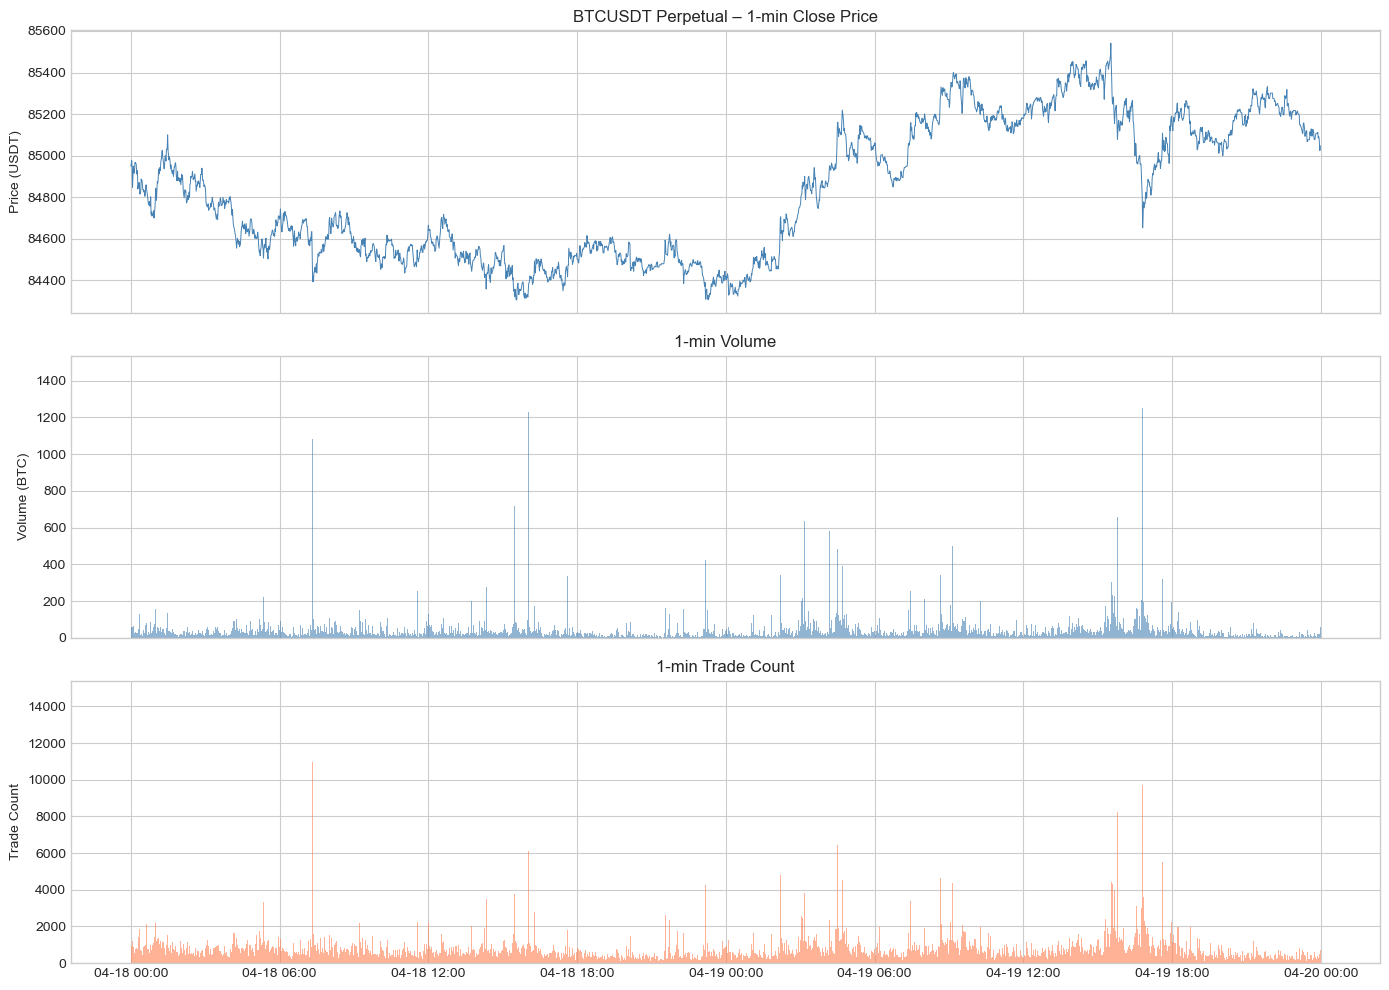

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
bars_1m = aggregate_ohlcv(trades, '1min')
axes[0].plot(bars_1m.index, bars_1m['close'], linewidth=0.7, color='steelblue')
axes[0].set_ylabel('Price (USDT)')
axes[0].set_title('BTCUSDT Perpetual – 1-min Close Price')

# Volume
axes[1].bar(bars_1m.index, bars_1m['volume'], width=1/1440, color='steelblue', alpha=0.6)
axes[1].set_ylabel('Volume (BTC)')
axes[1].set_title('1-min Volume')

# Trade count
axes[2].bar(bars_1m.index, bars_1m['trade_count'], width=1/1440, color='coral', alpha=0.6)
axes[2].set_ylabel('Trade Count')
axes[2].set_title('1-min Trade Count')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 1.4 Return Distribution

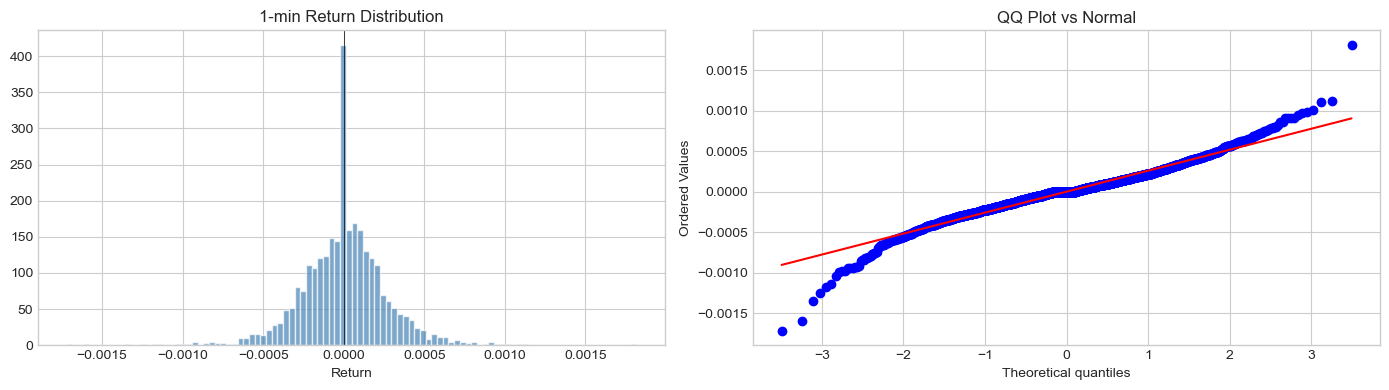

Skewness: -0.1413
Kurtosis: 3.5557
Mean: 0.000000
Std: 0.000264


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

returns = bars_1m['returns'].dropna()
axes[0].hist(returns, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('1-min Return Distribution')
axes[0].set_xlabel('Return')
axes[0].axvline(0, color='black', linewidth=0.5)

# QQ plot vs normal
from scipy import stats
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot vs Normal')

plt.tight_layout()
plt.show()

print(f"Skewness: {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurtosis():.4f}")
print(f"Mean: {returns.mean():.6f}")
print(f"Std: {returns.std():.6f}")

## 1.5 Autocorrelation Analysis

Check for mean-reverting vs trending behavior at short horizons.

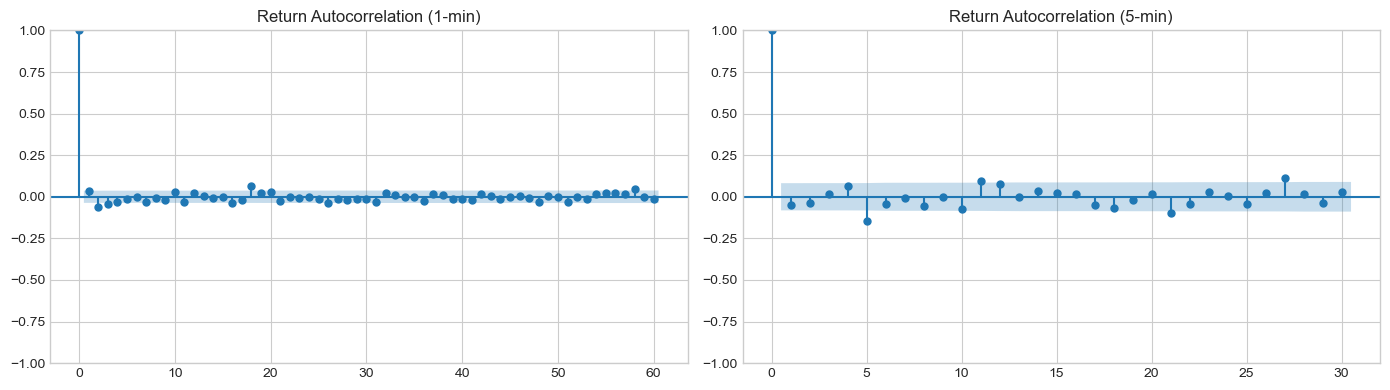

1-min return autocorrelations (lag 1-5):
  lag 1: 0.0342
  lag 2: -0.0611
  lag 3: -0.0446
  lag 4: -0.0310
  lag 5: -0.0119


In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(returns.dropna(), lags=60, ax=axes[0], title='Return Autocorrelation (1-min)')

# Also check 5-min returns
bars_5m = aggregate_ohlcv(trades, '5min')
ret_5m = bars_5m['returns'].dropna()
plot_acf(ret_5m, lags=30, ax=axes[1], title='Return Autocorrelation (5-min)')

plt.tight_layout()
plt.show()

print("1-min return autocorrelations (lag 1-5):")
for lag in range(1, 6):
    ac = returns.autocorr(lag)
    print(f"  lag {lag}: {ac:.4f}")

## 1.6 Buy/Sell Imbalance & Microstructure

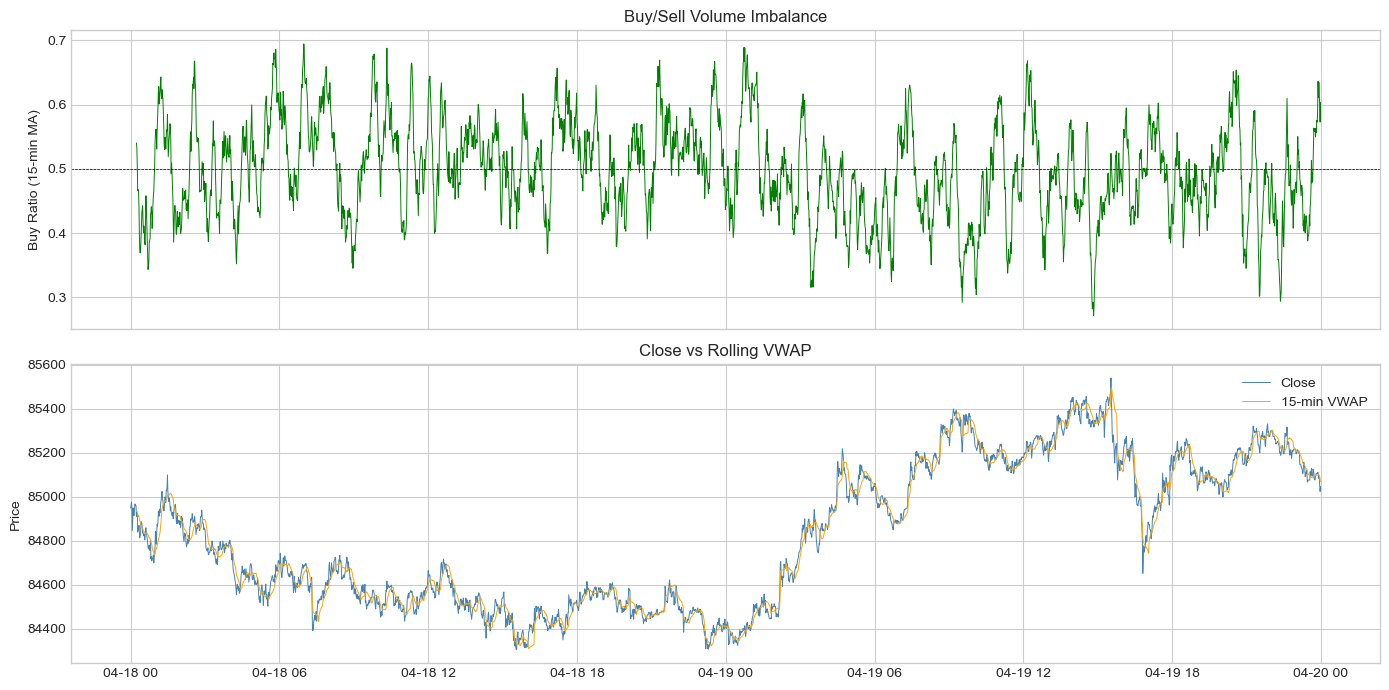

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Buy ratio over time
buy_ratio_smooth = bars_1m['buy_ratio'].rolling(15).mean()
axes[0].plot(bars_1m.index, buy_ratio_smooth, linewidth=0.7, color='green')
axes[0].axhline(0.5, color='black', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Buy Ratio (15-min MA)')
axes[0].set_title('Buy/Sell Volume Imbalance')

# VWAP vs close
axes[1].plot(bars_1m.index, bars_1m['close'], linewidth=0.7, label='Close', color='steelblue')
rolling_vwap = bars_1m['notional'].rolling(15).sum() / bars_1m['volume'].rolling(15).sum()
axes[1].plot(bars_1m.index, rolling_vwap, linewidth=0.7, label='15-min VWAP', color='orange')
axes[1].set_ylabel('Price')
axes[1].set_title('Close vs Rolling VWAP')
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.7 Intraday Patterns

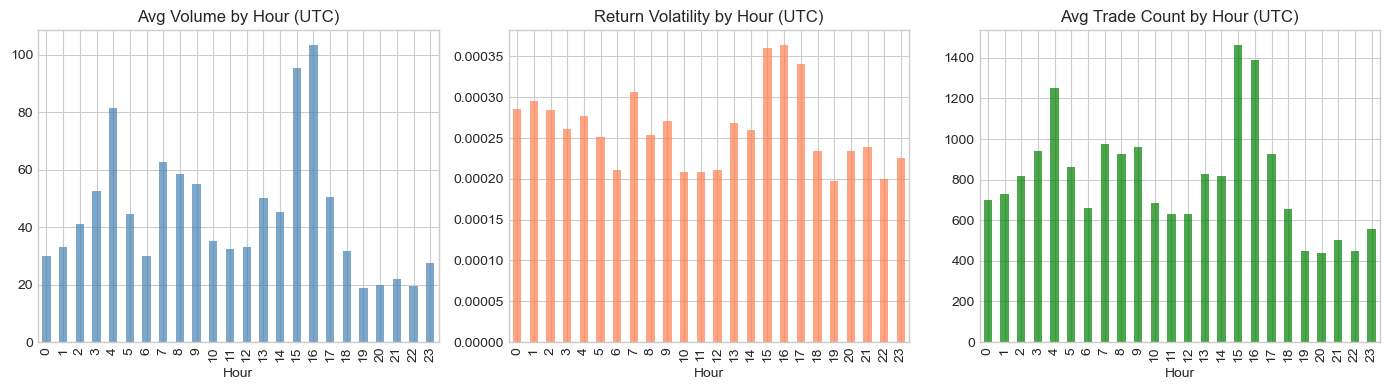

In [9]:
bars_1m['hour'] = bars_1m.index.hour

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Hourly volume profile
bars_1m.groupby('hour')['volume'].mean().plot.bar(ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Avg Volume by Hour (UTC)')
axes[0].set_xlabel('Hour')

# Hourly volatility
bars_1m.groupby('hour')['returns'].std().plot.bar(ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Return Volatility by Hour (UTC)')
axes[1].set_xlabel('Hour')

# Hourly trade count
bars_1m.groupby('hour')['trade_count'].mean().plot.bar(ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('Avg Trade Count by Hour (UTC)')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.show()

## 1.8 Summary

Key observations from this exploration:

1. **Data quality**: ~2.3M trades across 2 days, no missing values, continuous coverage.
2. **Return distribution**: Heavy tails (excess kurtosis) typical of crypto — signals should be robust to outliers.
3. **Autocorrelation**: Negative lag-1 autocorrelation at 1-min suggests mean-reverting microstructure — supports mean-reversion signals.
4. **Volume patterns**: Clear intraday seasonality — signals should account for volume regime.
5. **Order flow**: Buy/sell imbalance varies meaningfully and correlates with short-term price direction.

These findings motivate a signal suite weighted toward **mean-reversion** with **order flow** and **microstructure** features, which we develop in the next notebook.